# Bắt đầu

## Đề bài:  

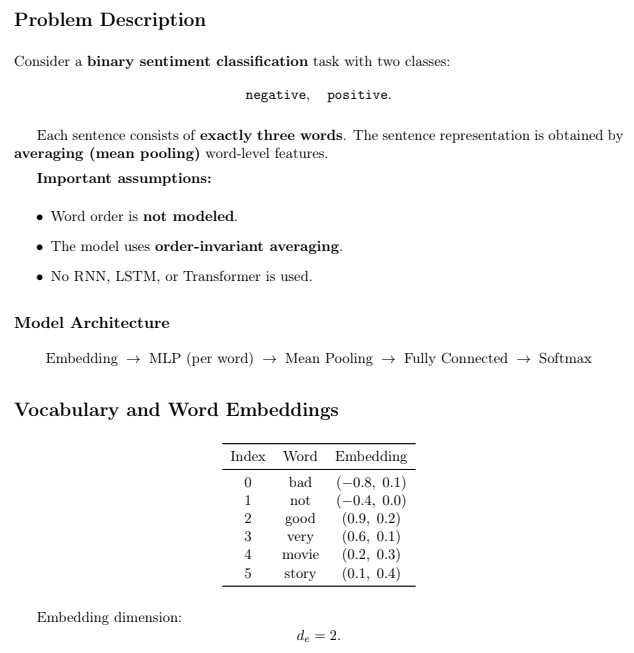  
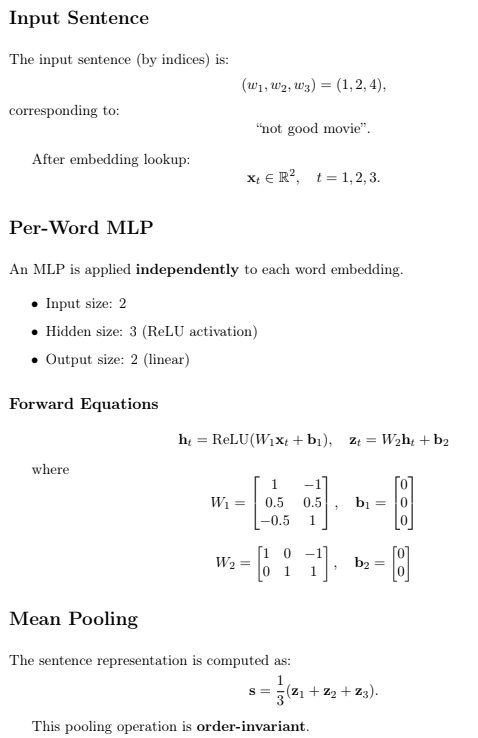  
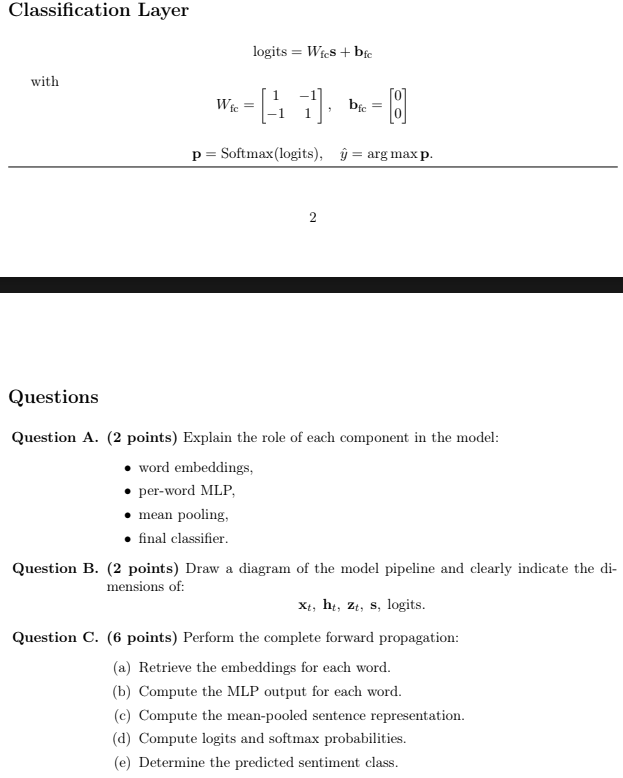

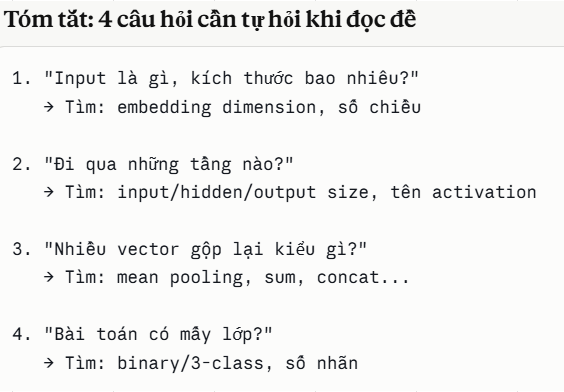  

## Bài giải:  

### <span style="color: blue">Câu A: Vai trò từng thành phần</span>  

* **Word Embeddings:** Chuyển từ (index) thành vector số thực. "not"→[−0.4, 0.0] — máy tính không hiểu chữ, chỉ hiểu số.  
* **Per-word MLP:** Áp dụng mạng nơ-ron độc lập cho từng từ để trích xuất đặc trưng sâu hơn từ embedding thô.  
* **Mean Pooling:** Lấy trung bình các vector từ → tạo ra 1 vector đại diện cho cả câu. Vì order-invariant nên không quan tâm thứ tự từ.  
* **Final Classifier:** Nhận vector câu → tính logits → softmax → xác suất 2 lớp (negative/positive).  

### <span style="color: blue">Câu B: Sơ đồ pipeline với kích thước</span>  

* **Bước 1: Hiểu nguyên tắc: kích thước đến từ đâu?**  
Mỗi phép tính có input và output, kích thước output phụ thuộc vào ma trận biến đổi:  

$\underbrace{(m \times n)}_{\text{ma trận}} \times \underbrace{(n \times 1)}_{\text{vetor vào}} = \underbrace{(m \times 1)}_{\text{vetor ra}}$  

<u><i>Quy tắc:</i></u> hàng của ma trận = kích thước output, cột của ma trận =  kích thước input.  

* **Bước 2: Xác định kích thước từng biến**  

Dựa vào đề ta có:  

|STT|Thông tin từ đề|Suy ra|  
|---|:---|:---|  
|1|Embedding dimension $d_e=2$|$x_t \in \mathbb{R}^2$ -> (2x1)|  
|2|Hidden size MLP = 3|$h_t \in \mathbb{R}^3$ -> (3x1)| 
|3|Output MLP = 2(linear)|$z_t \in \mathbb{R}^2$ -> (2x1)| 
|4|Mean pooling của $z_t$|s cùng kích thước $z_t$ -> (2x1)|  
|5|Số lớp phân loại = 2|logits $\in \mathbb{R}^2$ -> (2x1)|  
|6|Softmax giữ nguyên kích thước|p $\in \mathbb{R}^2$ -> (2x1)|  

<u><i>Giải thích mục 4 (Mean pooling):</i></u>  

Ta có: $z_t \in \mathbb{R}^2\quad$ 
và s = $\frac{1}{3}\cdot(z_1 + z_2 +z_3)$ = $\frac{1}{3}\cdot$((2x1) + (2x1) + (2x1)) = (2x1) => **s cùng kích thước $z_t$ -> (2x1)**  

<u><i>Giải thíc mục 5 (Số lớp phân loại):</i></u>  

Theo đề bài ta có:  
"binary sentiment classification" " two classes: negative, positive"  
Từ đó ta có 2 lớp -> cần 2 điểm số (mỗi lớp 1 điểm) -> logits = (2x1)  

<u><i>Quy tắc: </i></u> Số lớp bằng bao nhiêu thì logits có bấy nhiêu phần từ  

Ví dụ:  

|Bài toán|Số lớp| Kích thước logits|  
|---|---|---|  
|binary|2|(2x1)|  
|3 lớp (pos/neg/neutral)|3|(3x1)|  
|10 lớp (chữ số 0 -> 9)|10|(10x1)|  

<u><i>Giải thích mục 6 (Softmax): </i></u>  

Theo đề bài ta có: *p = Softmax(logits)*  
Vì: Softmax chỉ biến mỗi số thành xác xuất, không làm thay đổi kích thước nên ta có Input (2x1) -> Output(2x1)  

<u><i>Quy tắc: </i></u>  
**ReLU, Softmax, Sigmoid, tanh** đều **không đổi kích thước**, chúng chỉ iến đổi giá trị, không biến đổi hình dạng  


|Pipeline|  
|---|  
|$\underbrace{x_t}_{\text (2 \times 1)}$ -> $\underbrace{W_1}_{\text (3 \times 2)} + b_1$ -> $\underbrace{a_t}_{\text (3 \times 1)}$ -> ReLU -> $\underbrace{h_t}_{\text (3 \times 1)}$ -> $\underbrace{W_2}_{\text (2 \times 3)} + b_2$ -> $\underbrace{z_t}_{\text (2 \times 1)}$ -> (lặp 3 từ) -> z1, z2, z3 -> mean $\div$ 3 -> $\underbrace{s}_{\text (2 \times 1)}$ -> $\underbrace{W_fc}_{\text (2 \times 2)} + b_fc$ -> $\underbrace{logits}_{\text (2 \times 1)}$ -> softmax -> $\underbrace{p}_{\text (2 \times 1)}$ -> argmax -> $\hat{y}$|  







 






### <span style="color: blue">Câu C: Forward Propagation từng bước</span>  

* <span style="color: green">C.a) Lấy embedding cho từng từ</span>  

Bảng Embeddings  

|Index|Word|Embedding|  
|---|---|---|  
|0|bad|(-0.8, 0.1)|  
|1|not|(-0.4, 0.0)|  
|2|good|(0.9, 0.2)|  
|3|very|(0.6, 0.1)|  
|4|movie|(0.2, 0.3)|  
|5|story|(0.1, 0.4)|  

Theo đề bài ta có câu: (w1, w2, w3) = (1, 2, 4) tức là "not good movie"  

Dựa vào bảng embedding ta có  
|t|Index|Từ|Embedding|  
|---|---|---|---|  
|t=1|1|not|$x_1 = \begin{bmatrix} -0.4 \\ 0.0 \end{bmatrix}$|  
|t=2|2|good|$x_2 = \begin{bmatrix} 0.9 \\ 0.2 \end{bmatrix}$|  
|t=3|4|movie|$x_3 = \begin{bmatrix} 0.2 \\ 0.3 \end{bmatrix}$|  

* <span style="color: green">C.b) Tính MLP output cho từng từ</span>  

Theo đề bài ta có:  

$W_1 = \begin{bmatrix} 1 & -1 \\ 0.5 & 0.5 \\ -0.5 & 1 \end{bmatrix}\quad$ ; $\quad b_1 = \begin{bmatrix} 0 \\ 0 \\ 0 \end{bmatrix}\quad$ ; $\quad W_2 = \begin{bmatrix} 1 & 0 & -1 \\ 0 & 1 & 1 \end{bmatrix}\quad$ ; $\quad b_2 = \begin{bmatrix} 0 \\ 0 \end{bmatrix}$  

với: 
$h_t = ReLU(W_1 \cdot x_t + b_1)\quad$,  $\quad z_t = W_2 \cdot h_t + b_2$  

**<u><i>Với t =  1:</i></u>**  

$h_1 = ReLU(\begin{bmatrix} 1 & -1 \\ 0.5 & 0.5 \\ -0.5 & 1 \end{bmatrix} \begin{bmatrix} -0.4 \\ 0.0 \end{bmatrix} + \begin{bmatrix} 0 \\ 0 \\ 0 \end{bmatrix}) = ReLU(\begin{bmatrix} -0.4 \\ -0.2 \\ 0.2 \end{bmatrix}) = ReLU \begin{bmatrix} max(-0.4, 0) \\ max(-0.2, 0) \\ max(0, 0.2) \end{bmatrix} = \begin{bmatrix} 0 \\ 0 \\ 0.2 \end{bmatrix}$  

$z_1 = \begin{bmatrix} 1 & 0 & -1 \\ 0 & 1 & 1 \end{bmatrix} \begin{bmatrix} 0 \\ 0 \\ 0.2 \end{bmatrix} + \begin{bmatrix} 0 \\ 0 \end{bmatrix} =  \begin{bmatrix} -0.2 \\ 0.2 \end{bmatrix}$  

**<u><i>Với t = 2: </i></u>**  

$h_2 = ReLU(\begin{bmatrix} 1 & -1 \\ 0.5 & 0.5 \\ -0.5 & 1 \end{bmatrix} \begin{bmatrix} 0.9 \\ 0.2 \end{bmatrix} + \begin{bmatrix} 0 \\ 0 \\ 0 \end{bmatrix})= ReLU \begin{bmatrix} max(0, 0.7) \\ max(0, 0.55) \\ max(-0.25, 0) \end{bmatrix} =  \begin{bmatrix} 0.7 \\ 0.55 \\ 0 \end{bmatrix}$  

$z_2 = \begin{bmatrix} 1 & 0 & -1 \\ 0 & 1 & 1 \end{bmatrix} \begin{bmatrix} 0.7 \\ 0.55 \\ 0 \end{bmatrix} + \begin{bmatrix} 0 \\ 0 \end{bmatrix} = \begin{bmatrix} 0.7 \\ 0.55 \end{bmatrix}$  

**<u><i>Với t = 3: </i></u>**  

$h_3 = ReLU(\begin{bmatrix} 1 & -1 \\ 0.5 & 0.5 \\ -0.5 & 1 \end{bmatrix} \begin{bmatrix} 0.2 \\ 0.3 \end{bmatrix} + \begin{bmatrix} 0 \\ 0 \end{bmatrix}) = ReLU \begin{bmatrix} max(-0.1, 0) \\ max(0, 0.25) \\ maxx(0, 0.1) \end{bmatrix} = \begin{bmatrix} 0 \\ 0.25 \\ 0.2 \end{bmatrix}$  

$z_3 = \begin{bmatrix} 1 & 0 & -1 \\ 0 & 1 & 1 \end{bmatrix} \begin{bmatrix} 0 \\ 0.25 \\ 0.2 \end{bmatrix} + \begin{bmatrix} 0 \\ 0 \end{bmatrix} = \begin{bmatrix} -0.2 \\ 0.45 \end{bmatrix}$  

* <span style="color:green">C.c) Tính Mean-pooled</span>  

Từ đề bài ta có: s = $\frac{1}{3}$ (z1 +z2 + z3)  

s = $\frac{1}{3}(\begin{bmatrix} -0.2 \\ 0.2 \end{bmatrix} + \begin{bmatrix} 0.7 \\ 0.55 \end{bmatrix} + \begin{bmatrix} -0.2 \\ 0.45 \end{bmatrix}) = \frac{1}{3} \begin{bmatrix} 0.3 \\ 1.2 \end{bmatrix} = \begin{bmatrix} 0.1 \\ 0.4 \end{bmatrix}$  

* <span style="color: green">C.d) Tính logits và softmax</span>  

Theo đề bài ta có: **logits = $W_fc \cdot$ s + $b_fc$**  

$W_fc = \begin{bmatrix} 1 & -1 \\ -1 & 1 \end{bmatrix}\quad , \quad b_fc = \begin{bmatrix} 0 \\ 0 \end{bmatrix}$  

logits = $\begin{bmatrix} 1 & -1 \\ -1 & 1 \end{bmatrix} \begin{bmatrix} 0.1 \\ 0.4 \end{bmatrix} + \begin{bmatrix} 0 \\ 0 \end{bmatrix} = \begin{bmatrix} -0.3 \\ 0.3 \end{bmatrix}$

**p=Softmax(logits)** 

Với $\text{softmax}(logits)_k$ = $\frac{e^{logits_k}}{\sum e^{logits_k}}$  

Ta đã có logits = $\begin{bmatrix} -0.3 \\ 0.3 \end{bmatrix}$ => $\begin{cases} 
                logits_1 = -0.3 \\
                logis_2 = 0.3\\
                \end{cases}$  

Từ đó ta sẽ có:  

* k = 1 (negative):  

$p_1 = \frac{e^{logits_1}}{e^{logits_1} + e^{logits_2}} = \frac{e^{-0.3}}{e^{-0.3} + e^0.3} = 0.3543$  

* k = 2 (positive):  

$p_2 = \frac{e^{logits_2}}{e^{logits_1} + e^{logits_2}} = \frac{e^{0.3}}{e^{0.3} + e^{-0.3}} = 0.6457$  







  




* <span style="color: green">C.d) Tính </span>   $\hat{y}$

Theo đề bài ta có: $\hat{y} = \text{argmax p}$   
**argmax là tìm vị trí (index) có giá trị lớn nhất, không phải giá trị đó => vị trí của phần từ lớn nhất trong vector**  

Từ đó ta có: p = $\begin{bmatrix} 0.3543 \\ 0.6457 \end{bmatrix}$ => $\hat{y} = \text{argmax} \begin{bmatrix} 0.3543 \\ 0.6457 \end{bmatrix} = 1$  (do 0.6457 > 0.3543)




# Kết thúc